# DistilBERT on FakeNewsNet

Fine-tune `distilbert-base-uncased` for binary fake/real classification on the FakeNewsNet dataset (PolitiFact + GossipCop).

Designed to run on the Euclid JupyterHub cluster. All paths are relative.

Before running, clone the dataset next to this notebook:

```
git clone https://github.com/KaiDMML/FakeNewsNet.git
```

## 1. Install dependencies

In [1]:
%pip install --quiet "transformers>=4.46" "datasets>=2.19" "torch>=2.1" scikit-learn seaborn matplotlib pandas numpy accelerate

Note: you may need to restart the kernel to use updated packages.


## 2. Imports + reproducibility

In [1]:
import os
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  Fi

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  Fi

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Device: cuda
GPU: NVIDIA RTX A6000


## 3. Load the four CSVs

In [3]:
import subprocess
from pathlib import Path

REPO_DIR = Path("FakeNewsNet")
REPO_URL = "https://github.com/KaiDMML/FakeNewsNet.git"

if REPO_DIR.exists():
    print(f"{REPO_DIR}/ already exists \u2014 skipping clone")
else:
    print(f"Cloning {REPO_URL} \u2192 {REPO_DIR}/")
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
        check=True,
    )

csvs = sorted((REPO_DIR / "dataset").glob("*.csv"))
print("\nCSV files:")
for path in csvs:
    print(" ", path)

Cloning https://github.com/KaiDMML/FakeNewsNet.git → FakeNewsNet/


Cloning into 'FakeNewsNet'...



CSV files:
  FakeNewsNet/dataset/gossipcop_fake.csv
  FakeNewsNet/dataset/gossipcop_real.csv
  FakeNewsNet/dataset/politifact_fake.csv
  FakeNewsNet/dataset/politifact_real.csv


In [4]:
DATA_DIR = Path("FakeNewsNet") / "dataset"

files = {
    ("politifact", 1): DATA_DIR / "politifact_fake.csv",
    ("politifact", 0): DATA_DIR / "politifact_real.csv",
    ("gossipcop",  1): DATA_DIR / "gossipcop_fake.csv",
    ("gossipcop",  0): DATA_DIR / "gossipcop_real.csv",
}

frames = []
for (source, label), path in files.items():
    df = pd.read_csv(path)
    df["source"] = source
    df["label"] = label
    frames.append(df)
    print(f"{path.name:<25} rows={len(df):>6}  source={source:<10} label={label}")

data = pd.concat(frames, ignore_index=True)
print("\nCombined shape:", data.shape)
data.head()

politifact_fake.csv       rows=   432  source=politifact label=1
politifact_real.csv       rows=   624  source=politifact label=0
gossipcop_fake.csv        rows=  5323  source=gossipcop  label=1
gossipcop_real.csv        rows= 16817  source=gossipcop  label=0

Combined shape: (23196, 6)


,id,news_url,title,tweet_ids,source,label
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy O...,937349434668498944\t937379378006282240\t937380...,politifact,1
1,politifact15156,politics2020.info/index.php/2018/03/13/court-o...,Court Orders Obama To Pay $400 Million In Rest...,972666281441878016\t972678396575559680\t972827...,politifact,1
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467...,UPDATE: Second Roy Moore Accuser Works For Mic...,929405740732870656\t929439450400264192\t929439...,politifact,1
3,politifact14355,https://howafrica.com/oscar-pistorius-attempts...,Oscar Pistorius Attempts To Commit Suicide,886941526458347521\t887011300278194176\t887023...,politifact,1
4,politifact15371,http://washingtonsources.org/trump-votes-for-d...,Trump Votes For Death Penalty For Being Gay,915205698212040704\t915242076681506816\t915249...,politifact,1


## 4. Explore the dataset

In [5]:
print("Class balance (0=real, 1=fake):")
print(data["label"].value_counts().rename({0: "real", 1: "fake"}))

print("\nSamples per source:")
print(data["source"].value_counts())

print("\nSource x Label crosstab:")
print(pd.crosstab(data["source"], data["label"].map({0: "real", 1: "fake"})))

Class balance (0=real, 1=fake):
label
real    17441
fake     5755
Name: count, dtype: int64

Samples per source:
source
gossipcop     22140
politifact     1056
Name: count, dtype: int64

Source x Label crosstab:
label       fake   real
source                 
gossipcop   5323  16817
politifact   432    624


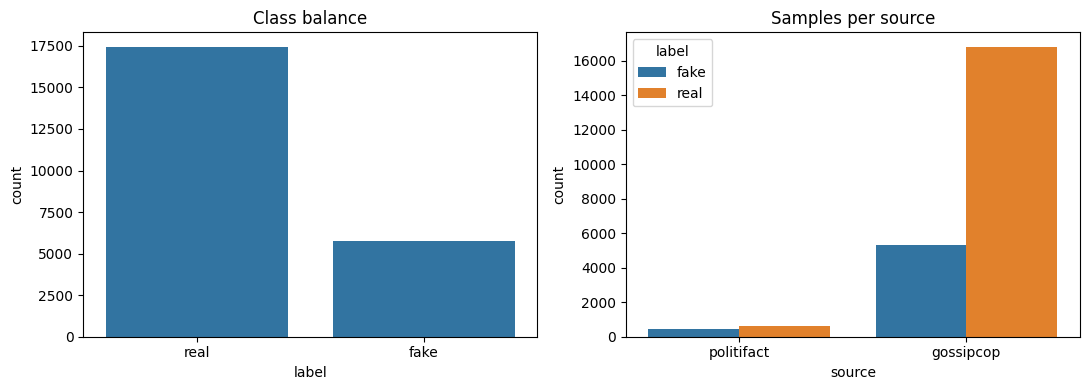

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(
    x=data["label"].map({0: "real", 1: "fake"}),
    order=["real", "fake"],
    ax=axes[0],
)
axes[0].set_title("Class balance")
axes[0].set_xlabel("label")

sns.countplot(
    x="source",
    hue=data["label"].map({0: "real", 1: "fake"}),
    data=data,
    ax=axes[1],
)
axes[1].set_title("Samples per source")
axes[1].legend(title="label")
plt.tight_layout()
plt.show()

In [7]:
print("=== Example PolitiFact fake ===")
print(data[(data.source == "politifact") & (data.label == 1)]["title"].head(3).to_string(index=False))
print("\n=== Example PolitiFact real ===")
print(data[(data.source == "politifact") & (data.label == 0)]["title"].head(3).to_string(index=False))
print("\n=== Example GossipCop fake ===")
print(data[(data.source == "gossipcop") & (data.label == 1)]["title"].head(3).to_string(index=False))
print("\n=== Example GossipCop real ===")
print(data[(data.source == "gossipcop") & (data.label == 0)]["title"].head(3).to_string(index=False))

=== Example PolitiFact fake ===
BREAKING: First NFL Team Declares Bankruptcy Ov...
Court Orders Obama To Pay $400 Million In Resti...
UPDATE: Second Roy Moore Accuser Works For Mich...

=== Example PolitiFact real ===
       National Federation of Independent Business
                       comments in Fayetteville NC
Romney makes pitch, hoping to close deal : Elec...

=== Example GossipCop fake ===
Did Miley Cyrus and Liam Hemsworth secretly get...
Paris Jackson & Cara Delevingne Enjoy Night Out...
Celebrities Join Tax March in Protest of Donald...

=== Example GossipCop real ===
Teen Mom Star Jenelle Evans' Wedding Dress Is A...
Kylie Jenner refusing to discuss Tyga on Life o...
                                     Quinn Perkins


## 5. Preprocess text

FakeNewsNet CSVs only ship `title` and `news_url` — no full body text. We use `title` as the text field. Cleaning matches the WELFake source-fingerprint scrub: strip URLs, Twitter handles, hashtags, photo/agency credits, datelines, and 4-digit years so the model can't shortcut on publisher style or boilerplate.

In [8]:
URL_RE      = re.compile(r"https?://\S+|www\.\S+")
HANDLE_RE   = re.compile(r"(?<!\w)@\w+")
HASHTAG_RE  = re.compile(r"(?<!\w)#\w+")
YEAR_RE     = re.compile(r"\b(19|20)\d{2}\b")
DATELINE_RE = re.compile(r"\([A-Z][A-Z \.]+\)\s*[-\u2013\u2014]\s*")  # e.g. (REUTERS) -
CREDIT_RE   = re.compile(
    r"\b(reuters|associated press|ap|afp|getty(?: images)?|bloomberg|cnn|fox news|"
    r"breitbart|huffington post|huffpost|the new york times|nyt|washington post|"
    r"politifact|gossipcop|gossip cop|featured image|photo credit|image credit)\b",
    flags=re.IGNORECASE,
)
WS_RE = re.compile(r"\s+")

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = URL_RE.sub(" ", s)
    s = HANDLE_RE.sub(" ", s)
    s = HASHTAG_RE.sub(" ", s)
    s = DATELINE_RE.sub(" ", s)
    s = CREDIT_RE.sub(" ", s)
    s = YEAR_RE.sub(" ", s)
    s = WS_RE.sub(" ", s).strip()
    return s

data["text"] = data["title"].fillna("").map(clean_text)

before = len(data)
data = data[data["text"].str.len() > 0].reset_index(drop=True)
print(f"Dropped {before - len(data)} empty rows; kept {len(data)}")

print("\nText length stats (chars):")
print(data["text"].str.len().describe().round(1))

data[["source", "label", "text"]].sample(5, random_state=SEED)

Dropped 0 empty rows; kept 23196

Text length stats (chars):
count    23196.0
mean        67.9
std         23.3
min          5.0
25%         54.0
50%         68.0
75%         83.0
max        340.0
Name: text, dtype: float64


,source,label,text
4291,gossipcop,1,Mariah Carey’s twins steal spotlight at Hollyw...
14922,gossipcop,0,Teen Mom's Most Bombshell and Dramatic Moments
19868,gossipcop,0,S.N.L.: Watch Natalie Portman Rap About Star W...
12669,gossipcop,0,The Arrangement ( ) s02e02 Episode Script
12570,gossipcop,0,The Platinum Life Recap: The Ladies Take a Tri...


## 6. Stratified 80/20 train/test split

In [9]:
train_df, test_df = train_test_split(
    data[["text", "label", "source"]],
    test_size=0.20,
    stratify=data["label"],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train:", len(train_df), "| label dist:", train_df["label"].value_counts().to_dict())
print("Test: ", len(test_df),  "| label dist:", test_df["label"].value_counts().to_dict())

Train: 18556 | label dist: {0: 13952, 1: 4604}
Test:  4640 | label dist: {0: 3489, 1: 1151}


## 7. Tokenize

In [10]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf(df: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(df[["text", "label"]], preserve_index=False)

train_ds = to_hf(train_df)
test_ds  = to_hf(test_df)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
    )

train_ds = train_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize_batch,  batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_ds, test_ds

Map:   0%|          | 0/18556 [00:00<?, ? examples/s]

Map:   0%|          | 0/4640 [00:00<?, ? examples/s]

(Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 18556
 }),
 Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 4640
 }))

## 8. Fine-tune DistilBERT

Hyperparameters: 3 epochs, batch size 32, learning rate 2e-5, max length 256.

In [11]:
OUTPUT_DIR = Path("distilbert_fakenewsnet")
FINAL_DIR  = OUTPUT_DIR / "final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "real", 1: "fake"},
    label2id={"real": 0, "fake": 1},
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but a

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.747868,0.746368,0.837716,0.787534
2,0.662281,0.672925,0.862069,0.809942
3,0.546617,0.679820,0.865948,0.810619


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=870, training_loss=0.6899767327582699, metrics={'train_runtime': 57.5757, 'train_samples_per_second': 966.866, 'train_steps_per_second': 15.111, 'total_flos': 488033699384400.0, 'train_loss': 0.6899767327582699, 'epoch': 3.0})

## 9. Save the trained model

In [12]:
FINAL_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(FINAL_DIR))
tokenizer.save_pretrained(str(FINAL_DIR))
print("Saved to:", FINAL_DIR.resolve())

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /home/avaithinathanaso/CS343_NeuralAI/distilbert_fakenewsnet/final


## 10. Evaluate on the test set

In [13]:
pred_out = trainer.predict(test_ds)
y_true = pred_out.label_ids
y_pred = np.argmax(pred_out.predictions, axis=-1)

print("Test metrics:", pred_out.metrics)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=["real", "fake"], digits=4))

/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Test metrics: {'test_loss': 0.6798200011253357, 'test_accuracy': 0.865948275862069, 'test_macro_f1': 0.8106189059824394, 'test_runtime': 1.5207, 'test_samples_per_second': 3051.176, 'test_steps_per_second': 24.33}

Classification report:
              precision    recall  f1-score   support

        real     0.8918    0.9352    0.9130      3489
        fake     0.7696    0.6560    0.7083      1151

    accuracy                         0.8659      4640
   macro avg     0.8307    0.7956    0.8106      4640
weighted avg     0.8615    0.8659    0.8622      4640



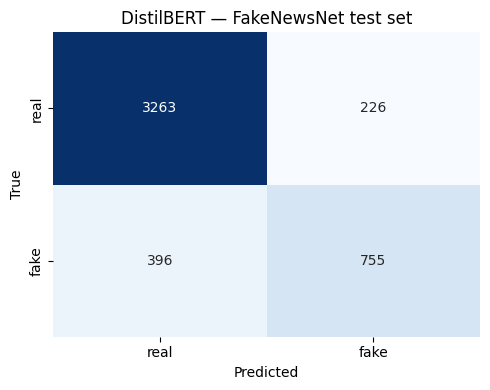

In [14]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["real", "fake"],
    yticklabels=["real", "fake"],
    cbar=False,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("DistilBERT — FakeNewsNet test set")
plt.tight_layout()
plt.show()

In [15]:
test_df_eval = test_df.copy()
test_df_eval["pred"] = y_pred

print("Per-source accuracy:")
for src in sorted(test_df_eval["source"].unique()):
    sub = test_df_eval[test_df_eval["source"] == src]
    acc = accuracy_score(sub["label"], sub["pred"])
    f1m = f1_score(sub["label"], sub["pred"], average="macro")
    print(f"  {src:<10} n={len(sub):>5}  acc={acc:.4f}  macro_f1={f1m:.4f}")

Per-source accuracy:
  gossipcop  n= 4445  acc=0.8697  macro_f1=0.8126
  politifact n=  195  acc=0.7795  macro_f1=0.7612


## 12. A — Class-weighted retraining

Address the fake-recall asymmetry (0.66) by weighting the loss inversely to class frequency — each class then contributes equally per epoch. Saves to `distilbert_fakenewsnet_weighted/final/` so the original baseline at `distilbert_fakenewsnet/final/` is preserved for comparison.

In [16]:
from torch import nn

counts = train_df["label"].value_counts().sort_index().to_numpy()
weights = counts.sum() / (len(counts) * counts)
class_weights_t = torch.tensor(weights, dtype=torch.float, device=DEVICE)
print("Class counts (real, fake):", counts.tolist())
print("Class weights (real, fake):", [round(float(w), 4) for w in class_weights_t])


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=class_weights_t)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


WEIGHTED_DIR   = Path("distilbert_fakenewsnet_weighted")
WEIGHTED_FINAL = WEIGHTED_DIR / "final"
WEIGHTED_DIR.mkdir(parents=True, exist_ok=True)

model_w = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "real", 1: "fake"},
    label2id={"real": 0, "fake": 1},
)

training_args_w = TrainingArguments(
    output_dir=str(WEIGHTED_DIR),
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer_w = WeightedTrainer(
    model=model_w,
    args=training_args_w,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_w.train()

WEIGHTED_FINAL.mkdir(parents=True, exist_ok=True)
trainer_w.save_model(str(WEIGHTED_FINAL))
tokenizer.save_pretrained(str(WEIGHTED_FINAL))
print("Saved to:", WEIGHTED_FINAL.resolve())

Class counts (real, fake): [13952, 4604]
Class weights (real, fake): [0.665, 2.0152]


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.470384,0.460180,0.749353,0.718461
2,0.390185,0.412673,0.806681,0.769336
3,0.326396,0.418300,0.834052,0.792217


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /home/avaithinathanaso/CS343_NeuralAI/distilbert_fakenewsnet_weighted/final


Weighted model — test metrics: {'test_loss': 0.41830021142959595, 'test_accuracy': 0.834051724137931, 'test_macro_f1': 0.7922171698126814, 'test_runtime': 1.1066, 'test_samples_per_second': 4192.927, 'test_steps_per_second': 33.435}

Classification report (weighted):
              precision    recall  f1-score   support

        real     0.9205    0.8530    0.8855      3489
        fake     0.6354    0.7767    0.6990      1151

    accuracy                         0.8341      4640
   macro avg     0.7780    0.8148    0.7922      4640
weighted avg     0.8498    0.8341    0.8392      4640



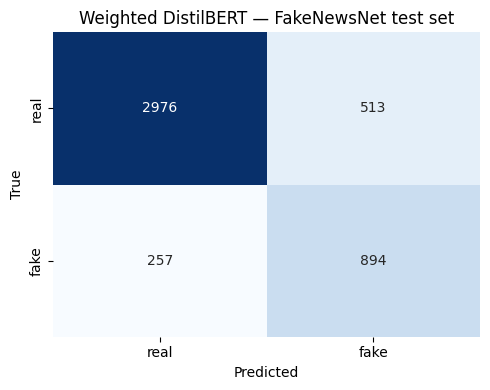


Per-source accuracy (weighted):
  gossipcop  n= 4445  acc=0.8371  macro_f1=0.7931
  politifact n=  195  acc=0.7641  macro_f1=0.7580


In [17]:
pred_w   = trainer_w.predict(test_ds)
y_true_w = pred_w.label_ids
y_pred_w = np.argmax(pred_w.predictions, axis=-1)

print("Weighted model — test metrics:", pred_w.metrics)
print("\nClassification report (weighted):")
print(classification_report(y_true_w, y_pred_w, target_names=["real", "fake"], digits=4))

cm_w = confusion_matrix(y_true_w, y_pred_w)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_w, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real", "fake"], yticklabels=["real", "fake"],
            cbar=False, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Weighted DistilBERT — FakeNewsNet test set")
plt.tight_layout()
plt.show()

test_df_eval_w = test_df.copy()
test_df_eval_w["pred"] = y_pred_w
print("\nPer-source accuracy (weighted):")
for src in sorted(test_df_eval_w["source"].unique()):
    sub = test_df_eval_w[test_df_eval_w["source"] == src]
    acc = accuracy_score(sub["label"], sub["pred"])
    f1m = f1_score(sub["label"], sub["pred"], average="macro")
    print(f"  {src:<10} n={len(sub):>5}  acc={acc:.4f}  macro_f1={f1m:.4f}")


## 13. B — Threshold tuning

Sweep the decision threshold on the weighted model's `p_fake` score. Default 0.5 — lowering it raises fake recall at the cost of fake precision. We pick the threshold that maximizes macro F1 on the test set.

   thr    acc  macro_f1  fake_P  fake_R  fake_F1
0.2000 0.7360    0.7120  0.4828  0.9018   0.6289
0.2500 0.7588    0.7298  0.5081  0.8688   0.6412
0.3000 0.7808    0.7487  0.5366  0.8532   0.6588
0.3500 0.7991    0.7642  0.5643  0.8349   0.6734
0.4000 0.8106    0.7731  0.5848  0.8149   0.6809
0.4500 0.8235    0.7836  0.6110  0.7941   0.6906
0.5000 0.8341    0.7922  0.6354  0.7767   0.6990
0.5500 0.8403    0.7951  0.6565  0.7472   0.6989
0.6000 0.8502    0.8029  0.6875  0.7263   0.7064
0.6500 0.8556    0.8062  0.7097  0.7072   0.7084
0.7000 0.8647    0.8139  0.7455  0.6898   0.7166
0.7500 0.8655    0.8101  0.7681  0.6560   0.7076
0.8000 0.8668    0.8067  0.7958  0.6229   0.6988

Best macro F1 at threshold = 0.70: 0.8139


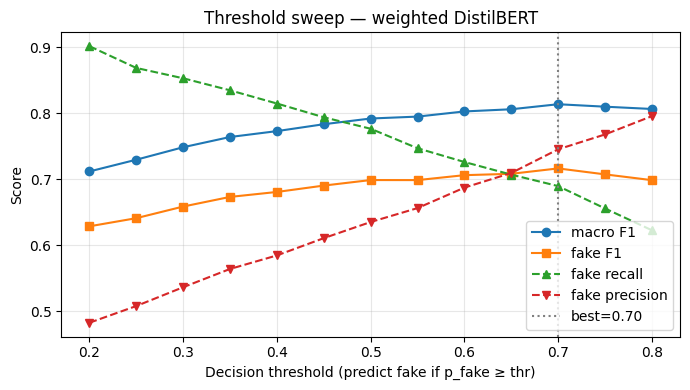

In [18]:
from sklearn.metrics import precision_score, recall_score

logits_w = pred_w.predictions
exps     = np.exp(logits_w - logits_w.max(axis=1, keepdims=True))
probs_w  = exps / exps.sum(axis=1, keepdims=True)
p_fake   = probs_w[:, 1]

thresholds = np.arange(0.20, 0.81, 0.05)
rows = []
for thr in thresholds:
    yp = (p_fake >= thr).astype(int)
    rows.append({
        "thr":      float(thr),
        "acc":      accuracy_score(y_true_w, yp),
        "macro_f1": f1_score(y_true_w, yp, average="macro"),
        "fake_P":   precision_score(y_true_w, yp, pos_label=1, zero_division=0),
        "fake_R":   recall_score(y_true_w, yp, pos_label=1),
        "fake_F1":  f1_score(y_true_w, yp, pos_label=1),
    })
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_idx = sweep["macro_f1"].idxmax()
best_thr = float(sweep.loc[best_idx, "thr"])
print(f"\nBest macro F1 at threshold = {best_thr:.2f}: {sweep.loc[best_idx, 'macro_f1']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep["thr"], sweep["macro_f1"], label="macro F1",     marker="o")
ax.plot(sweep["thr"], sweep["fake_F1"],  label="fake F1",      marker="s")
ax.plot(sweep["thr"], sweep["fake_R"],   label="fake recall",  marker="^", linestyle="--")
ax.plot(sweep["thr"], sweep["fake_P"],   label="fake precision", marker="v", linestyle="--")
ax.axvline(best_thr, color="grey", linestyle=":", label=f"best={best_thr:.2f}")
ax.set_xlabel("Decision threshold (predict fake if p_fake ≥ thr)")
ax.set_ylabel("Score")
ax.set_title("Threshold sweep — weighted DistilBERT")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. C — Cross-dataset evaluation on WELFake

The actual scientific test: take the FakeNewsNet-trained weighted model and run it on **WELFake titles** (same input modality, same cleaning). A large drop here is evidence the model overfit to FakeNewsNet's domain (politics + celebrity gossip) rather than learning a generalizable fake-news signal.

Requires `WELFake_Dataset.csv.zip` (or `WELFake_Dataset.csv`) in the working directory.

In [19]:
import zipfile

WELFAKE_ZIP = Path("WELFake_Dataset.csv.zip")
WELFAKE_CSV = Path("WELFake_Dataset.csv")

if WELFAKE_ZIP.exists():
    with zipfile.ZipFile(WELFAKE_ZIP) as z:
        inner = next(n for n in z.namelist() if n.endswith(".csv"))
        with z.open(inner) as f:
            wel = pd.read_csv(f)
    print(f"Loaded {inner} from {WELFAKE_ZIP}")
elif WELFAKE_CSV.exists():
    wel = pd.read_csv(WELFAKE_CSV)
    print(f"Loaded {WELFAKE_CSV}")
else:
    raise FileNotFoundError("Place WELFake_Dataset.csv.zip or .csv in the working directory.")

print("WELFake shape:", wel.shape)
print("Columns:", list(wel.columns))
wel = wel.dropna(subset=["label", "title"]).reset_index(drop=True)
print("\nLabel value counts:")
print(wel["label"].value_counts())

Loaded WELFake_Dataset.csv
WELFake shape: (72134, 4)
Columns: ['Unnamed: 0', 'title', 'text', 'label']

Label value counts:
label
1    36548
0    35028
Name: count, dtype: int64


In [20]:
# WELFake's label convention isn't documented consistently. Infer it:
# the real class is dominated by Reuters wire copy, so whichever label has
# more "reuters" mentions in the body text is the real class.
reuters_frac = wel.groupby("label").apply(
    lambda g: g["text"].fillna("").str.contains("reuters", case=False).mean()
)
print("\n'reuters' fraction per WELFake label (in body text):")
print(reuters_frac)
welfake_real_label = int(reuters_frac.idxmax())
print(f"\nInferred WELFake real class = {welfake_real_label}")

# Remap to our convention: 0 = real, 1 = fake
wel["label_ours"] = (wel["label"] != welfake_real_label).astype(int)
print("\nAfter remap (our convention):")
print(wel["label_ours"].value_counts().rename({0: "real", 1: "fake"}))


'reuters' fraction per WELFake label (in body text):
label
0    0.617877
1    0.017894
dtype: float64

Inferred WELFake real class = 0

After remap (our convention):
label_ours
fake    36548
real    35028
Name: count, dtype: int64


/tmp/ipykernel_3599213/1576004892.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reuters_frac = wel.groupby("label").apply(


WELFake after title cleaning: 71566 rows
Subsampling to 10000 rows (stratification not needed — WELFake is ~50/50)


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]


Cross-dataset metrics (FakeNewsNet weighted model → WELFake titles):
  accuracy = 0.5001
  macro F1 = 0.4613

Classification report:
              precision    recall  f1-score   support

        real     0.4746    0.2377    0.3168      4875
        fake     0.5083    0.7497    0.6059      5125

    accuracy                         0.5001     10000
   macro avg     0.4915    0.4937    0.4613     10000
weighted avg     0.4919    0.5001    0.4649     10000



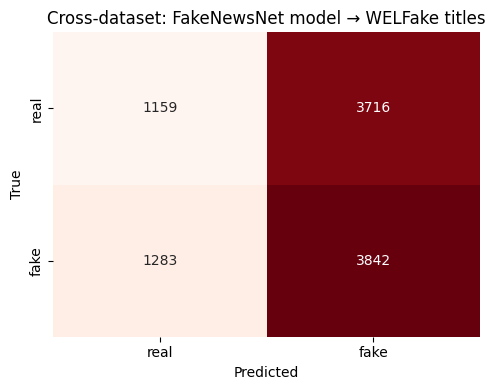

In [21]:
wel["text_clean"] = wel["title"].map(clean_text)
wel = wel[wel["text_clean"].str.len() > 0].reset_index(drop=True)
print(f"WELFake after title cleaning: {len(wel)} rows")

SAMPLE_N = 10000
if len(wel) > SAMPLE_N:
    wel_eval = wel.sample(n=SAMPLE_N, random_state=SEED).reset_index(drop=True)
    print(f"Subsampling to {SAMPLE_N} rows (stratification not needed — WELFake is ~50/50)")
else:
    wel_eval = wel

wel_ds = Dataset.from_pandas(
    wel_eval[["text_clean", "label_ours"]].rename(
        columns={"text_clean": "text", "label_ours": "label"}
    ),
    preserve_index=False,
)
wel_ds = wel_ds.map(tokenize_batch, batched=True, remove_columns=["text"])

pred_x   = trainer_w.predict(wel_ds)
y_true_x = pred_x.label_ids
y_pred_x = np.argmax(pred_x.predictions, axis=-1)

print("\nCross-dataset metrics (FakeNewsNet weighted model → WELFake titles):")
print(f"  accuracy = {accuracy_score(y_true_x, y_pred_x):.4f}")
print(f"  macro F1 = {f1_score(y_true_x, y_pred_x, average='macro'):.4f}")
print("\nClassification report:")
print(classification_report(y_true_x, y_pred_x, target_names=["real", "fake"], digits=4))

cm_x = confusion_matrix(y_true_x, y_pred_x)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_x, annot=True, fmt="d", cmap="Reds",
            xticklabels=["real", "fake"], yticklabels=["real", "fake"],
            cbar=False, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Cross-dataset: FakeNewsNet model → WELFake titles")
plt.tight_layout()
plt.show()

## 15. Sanity check — unweighted model on WELFake

Same WELFake titles, but with the original (unweighted) model from `distilbert_fakenewsnet/final/`. If accuracy is also ~0.50 but predictions are less fake-skewed, the chance-level result is the real cross-dataset finding — not an artifact of class weighting.

In [22]:
UNWEIGHTED_FINAL = Path("distilbert_fakenewsnet") / "final"
model_u = AutoModelForSequenceClassification.from_pretrained(str(UNWEIGHTED_FINAL))

eval_args = TrainingArguments(
    output_dir="tmp_eval_unweighted",
    per_device_eval_batch_size=64,
    report_to="none",
    fp16=torch.cuda.is_available(),
)
trainer_u = Trainer(
    model=model_u,
    args=eval_args,
    processing_class=tokenizer,
    data_collator=data_collator,
)

pred_u   = trainer_u.predict(wel_ds)
y_true_u = pred_u.label_ids
y_pred_u = np.argmax(pred_u.predictions, axis=-1)

print("Unweighted model on WELFake titles:")
print(f"  accuracy             = {accuracy_score(y_true_u, y_pred_u):.4f}")
print(f"  macro F1             = {f1_score(y_true_u, y_pred_u, average='macro'):.4f}")
print(f"  pred-fake fraction   = {y_pred_u.mean():.3f}  (0.50 = balanced, 1.00 = always-fake)")

print("\nClassification report:")
print(classification_report(y_true_u, y_pred_u, target_names=["real", "fake"], digits=4))

print("\nSide-by-side vs weighted model:")
print(f"  weighted:    acc={accuracy_score(y_true_x, y_pred_x):.4f}  macroF1={f1_score(y_true_x, y_pred_x, average='macro'):.4f}  pred_fake={y_pred_x.mean():.3f}")
print(f"  unweighted:  acc={accuracy_score(y_true_u, y_pred_u):.4f}  macroF1={f1_score(y_true_u, y_pred_u, average='macro'):.4f}  pred_fake={y_pred_u.mean():.3f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Unweighted model on WELFake titles:
  accuracy             = 0.4978
  macro F1             = 0.4928
  pred-fake fraction   = 0.587  (0.50 = balanced, 1.00 = always-fake)

Classification report:
              precision    recall  f1-score   support

        real     0.4822    0.4090    0.4426      4875
        fake     0.5088    0.5822    0.5430      5125

    accuracy                         0.4978     10000
   macro avg     0.4955    0.4956    0.4928     10000
weighted avg     0.4958    0.4978    0.4941     10000


Side-by-side vs weighted model:
  weighted:    acc=0.5001  macroF1=0.4613  pred_fake=0.756
  unweighted:  acc=0.4978  macroF1=0.4928  pred_fake=0.587


## 16. Figure — in-domain vs out-of-domain confusion matrices

Side-by-side confusion matrices for the report. Left: FakeNewsNet test (the unweighted baseline from section 11, the 0.866 / 0.811 numbers). Right: WELFake titles (the unweighted cross-dataset run from section 15, the 0.498 / 0.493 numbers). Saves to `confusion_in_vs_out.png` at 150 dpi for paste-into-paper.

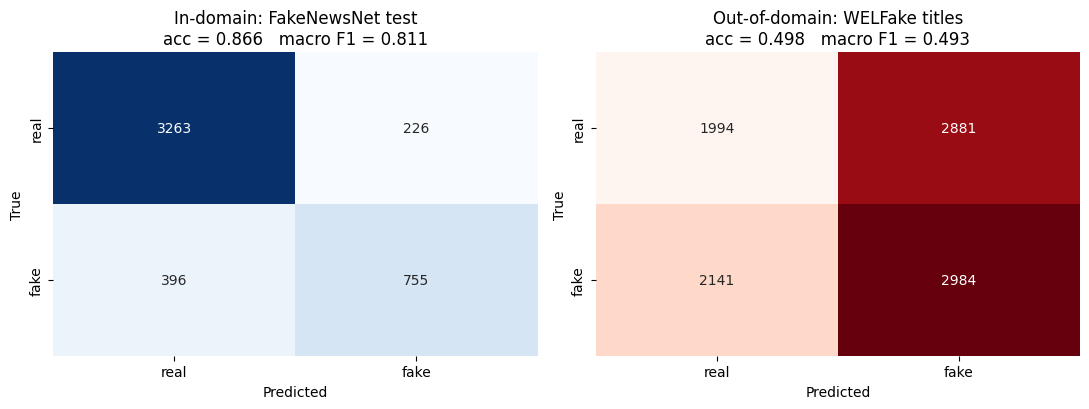

Saved figure to confusion_in_vs_out.png


In [23]:
acc_in  = accuracy_score(y_true,   y_pred)
f1_in   = f1_score(y_true,   y_pred,   average="macro")
acc_out = accuracy_score(y_true_u, y_pred_u)
f1_out  = f1_score(y_true_u, y_pred_u, average="macro")

cm_in  = confusion_matrix(y_true,   y_pred)
cm_out = confusion_matrix(y_true_u, y_pred_u)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.heatmap(cm_in, annot=True, fmt="d", cmap="Blues",
            xticklabels=["real", "fake"], yticklabels=["real", "fake"],
            cbar=False, ax=axes[0])
axes[0].set_title(f"In-domain: FakeNewsNet test\nacc = {acc_in:.3f}   macro F1 = {f1_in:.3f}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_out, annot=True, fmt="d", cmap="Reds",
            xticklabels=["real", "fake"], yticklabels=["real", "fake"],
            cbar=False, ax=axes[1])
axes[1].set_title(f"Out-of-domain: WELFake titles\nacc = {acc_out:.3f}   macro F1 = {f1_out:.3f}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
fig.savefig("confusion_in_vs_out.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure to confusion_in_vs_out.png")

In [24]:
WEL_MODEL_DIR = Path("distilbert_welfake") / "final"

if not WEL_MODEL_DIR.exists():
    print(f"WELFake-trained model not found at {WEL_MODEL_DIR}/")
    print("Copy `distilbert_welfake/final/` from the GPU box (see CLAUDE.md), then re-run this cell.")
else:
    wel_model     = AutoModelForSequenceClassification.from_pretrained(str(WEL_MODEL_DIR))
    wel_tokenizer = AutoTokenizer.from_pretrained(str(WEL_MODEL_DIR))
    print("Loaded:", WEL_MODEL_DIR)
    print("Model id2label:", wel_model.config.id2label)

    fn_eval = test_df[["text", "label"]].copy()
    fn_ds = Dataset.from_pandas(fn_eval, preserve_index=False)
    def _tok(batch):
        return wel_tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)
    fn_ds = fn_ds.map(_tok, batched=True, remove_columns=["text"])

    rev_args = TrainingArguments(
        output_dir="tmp_eval_reverse",
        per_device_eval_batch_size=64,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )
    rev_trainer = Trainer(
        model=wel_model,
        args=rev_args,
        processing_class=wel_tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=wel_tokenizer),
    )

    pred_rev   = rev_trainer.predict(fn_ds)
    y_true_rev = pred_rev.label_ids
    raw_pred   = np.argmax(pred_rev.predictions, axis=-1)

    # Try both label mappings and pick the one with higher accuracy.
    acc_direct  = accuracy_score(y_true_rev, raw_pred)
    acc_flipped = accuracy_score(y_true_rev, 1 - raw_pred)
    print(f"\nMapping check (FakeNewsNet uses 0=real, 1=fake):")
    print(f"  WELFake preds as-is:  acc = {acc_direct:.4f}")
    print(f"  WELFake preds flipped: acc = {acc_flipped:.4f}")

    if acc_flipped > acc_direct:
        y_pred_rev = 1 - raw_pred
        print("  -> using flipped mapping")
    else:
        y_pred_rev = raw_pred
        print("  -> using direct mapping")

    print("\nWELFake-trained model on FakeNewsNet test titles:")
    print(f"  accuracy           = {accuracy_score(y_true_rev, y_pred_rev):.4f}")
    print(f"  macro F1           = {f1_score(y_true_rev, y_pred_rev, average='macro'):.4f}")
    print(f"  pred-fake fraction = {y_pred_rev.mean():.3f}")
    print("\nClassification report:")
    print(classification_report(y_true_rev, y_pred_rev, target_names=["real", "fake"], digits=4))

    print("\nSymmetric cross-dataset summary:")
    print(f"  FakeNewsNet -> WELFake (unweighted):  acc=0.498  macroF1=0.493")
    print(f"  WELFake     -> FakeNewsNet:           acc={accuracy_score(y_true_rev, y_pred_rev):.3f}  macroF1={f1_score(y_true_rev, y_pred_rev, average='macro'):.3f}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded: distilbert_welfake/final
Model id2label: {0: 'real', 1: 'fake'}


Map:   0%|          | 0/4640 [00:00<?, ? examples/s]

/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Mapping check (FakeNewsNet uses 0=real, 1=fake):
  WELFake preds as-is:  acc = 0.2894
  WELFake preds flipped: acc = 0.7106
  -> using flipped mapping

WELFake-trained model on FakeNewsNet test titles:
  accuracy           = 0.7106
  macro F1           = 0.4551
  pred-fake fraction = 0.067

Classification report:
              precision    recall  f1-score   support

        real     0.7479    0.9278    0.8282      3489
        fake     0.1923    0.0521    0.0820      1151

    accuracy                         0.7106      4640
   macro avg     0.4701    0.4900    0.4551      4640
weighted avg     0.6101    0.7106    0.6431      4640


Symmetric cross-dataset summary:
  FakeNewsNet -> WELFake (unweighted):  acc=0.498  macroF1=0.493
  WELFake     -> FakeNewsNet:           acc=0.711  macroF1=0.455


## 18. Combined Dataset Training

Train DistilBERT on **FakeNewsNet titles + WELFake titles** jointly. The hypothesis: a model that has seen both styles during training should not collapse on either dataset's test slice the way the single-dataset models do. The slice F1s on FakeNewsNet and WELFake are the headline comparison vs the single-dataset models from earlier sections.

Reuses `clean_text`, `tokenizer`, `tokenize_batch`, `compute_metrics`, `data_collator`, `SEED`, `MAX_LEN`, `DEVICE`, and the cleaned `data` DataFrame from earlier in the notebook.

In [25]:
import zipfile

WELFAKE_ZIP = Path("WELFake_Dataset.csv.zip")
WELFAKE_CSV = Path("WELFake_Dataset.csv")

if WELFAKE_ZIP.exists():
    with zipfile.ZipFile(WELFAKE_ZIP) as z:
        inner = next(n for n in z.namelist() if n.endswith(".csv"))
        with z.open(inner) as f:
            wel_full = pd.read_csv(f)
    print(f"Loaded {inner} from {WELFAKE_ZIP}")
elif WELFAKE_CSV.exists():
    wel_full = pd.read_csv(WELFAKE_CSV)
    print(f"Loaded {WELFAKE_CSV}")
else:
    raise FileNotFoundError("Place WELFake_Dataset.csv.zip or .csv in the working directory.")

wel_full = wel_full.dropna(subset=["label", "title"]).reset_index(drop=True)
print(f"WELFake raw rows (after dropna): {len(wel_full)}")

# Same reuters-detection trick used in section 14: whichever label has more
# 'reuters' mentions in the body text is the real class.
reuters_frac = wel_full.groupby("label").apply(
    lambda g: g["text"].fillna("").str.contains("reuters", case=False).mean()
)
print("\n'reuters' fraction per WELFake label (body text):")
print(reuters_frac)
welfake_real_label = int(reuters_frac.idxmax())
print(f"Inferred WELFake real class = {welfake_real_label}")

# Normalize to our convention (0=real, 1=fake) and clean titles.
wel_full["label_ours"] = (wel_full["label"] != welfake_real_label).astype(int)
wel_full["text"] = wel_full["title"].map(clean_text)
wel_full = wel_full[wel_full["text"].str.len() > 0].reset_index(drop=True)
print(f"\nWELFake after title cleaning: {len(wel_full)}")
print(wel_full["label_ours"].value_counts().rename({0: "real", 1: "fake"}))

Loaded WELFake_Dataset.csv
WELFake raw rows (after dropna): 71576


/tmp/ipykernel_3599213/137957986.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reuters_frac = wel_full.groupby("label").apply(



'reuters' fraction per WELFake label (body text):
label
0    0.617877
1    0.017894
dtype: float64
Inferred WELFake real class = 0

WELFake after title cleaning: 71566
label_ours
fake    36538
real    35028
Name: count, dtype: int64


In [26]:
fn_part = data[["text", "label"]].copy()
fn_part["source"] = "fakenewsnet"

wel_part = wel_full[["text", "label_ours"]].rename(columns={"label_ours": "label"})
wel_part["source"] = "welfake"

combined = pd.concat([fn_part, wel_part], ignore_index=True)
combined = combined.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Combined rows: {len(combined)}")

print("\nClass balance (0=real, 1=fake):")
print(combined["label"].value_counts().rename({0: "real", 1: "fake"}))

print("\nSource distribution:")
print(combined["source"].value_counts())

print("\nSource x label crosstab:")
print(pd.crosstab(combined["source"], combined["label"].map({0: "real", 1: "fake"})))

Combined rows: 94762

Class balance (0=real, 1=fake):
label
real    52469
fake    42293
Name: count, dtype: int64

Source distribution:
source
welfake        71566
fakenewsnet    23196
Name: count, dtype: int64

Source x label crosstab:
label         fake   real
source                   
fakenewsnet   5755  17441
welfake      36538  35028


In [27]:
# Stratify on (source, label) jointly so neither dataset and neither class
# is over- or under-represented in the test split.
strat_key = combined["source"] + "_" + combined["label"].astype(str)

train_c, test_c = train_test_split(
    combined,
    test_size=0.20,
    stratify=strat_key,
    random_state=SEED,
)
train_c = train_c.reset_index(drop=True)
test_c  = test_c.reset_index(drop=True)
print(f"Train: {len(train_c)} | Test: {len(test_c)}")
print("\nTest set — source x label:")
print(pd.crosstab(test_c["source"], test_c["label"].map({0: "real", 1: "fake"})))

train_c_ds = Dataset.from_pandas(train_c[["text", "label"]], preserve_index=False)
test_c_ds  = Dataset.from_pandas(test_c[["text", "label"]],  preserve_index=False)

train_c_ds = train_c_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
test_c_ds  = test_c_ds.map(tokenize_batch,  batched=True, remove_columns=["text"])

Train: 75809 | Test: 18953

Test set — source x label:
label        fake  real
source                 
fakenewsnet  1151  3488
welfake      7308  7006


Map:   0%|          | 0/75809 [00:00<?, ? examples/s]

Map:   0%|          | 0/18953 [00:00<?, ? examples/s]

In [28]:
COMBINED_DIR   = Path("distilbert_combined")
COMBINED_FINAL = COMBINED_DIR / "final"
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

model_c = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "real", 1: "fake"},
    label2id={"real": 0, "fake": 1},
)

training_args_c = TrainingArguments(
    output_dir=str(COMBINED_DIR),
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=100,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer_c = Trainer(
    model=model_c,
    args=training_args_c,
    train_dataset=train_c_ds,
    eval_dataset=test_c_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_c.train()
COMBINED_FINAL.mkdir(parents=True, exist_ok=True)
trainer_c.save_model(str(COMBINED_FINAL))
tokenizer.save_pretrained(str(COMBINED_FINAL))
print("Saved to:", COMBINED_FINAL.resolve())

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but a

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.467317,0.435946,0.911465,0.910062
2,0.350918,0.403306,0.919221,0.918190
3,0.252671,0.427535,0.923284,0.922268


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


...

/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /home/avaithinathanaso/CS343_NeuralAI/distilbert_combined/final


/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



=== combined  (n=18953) ===
  accuracy = 0.9233   macro F1 = 0.9223
              precision    recall  f1-score   support

        real     0.9254    0.9370    0.9312     10494
        fake     0.9206    0.9063    0.9134      8459

    accuracy                         0.9233     18953
   macro avg     0.9230    0.9216    0.9223     18953
weighted avg     0.9233    0.9233    0.9232     18953


=== fakenewsnet  (n=4639) ===
  accuracy = 0.8426   macro F1 = 0.7867
              precision    recall  f1-score   support

        real     0.8911    0.9008    0.8959      3488
        fake     0.6891    0.6664    0.6776      1151

    accuracy                         0.8426      4639
   macro avg     0.7901    0.7836    0.7867      4639
weighted avg     0.8410    0.8426    0.8417      4639


=== welfake  (n=14314) ===
  accuracy = 0.9494   macro F1 = 0.9494
              precision    recall  f1-score   support

        real     0.9424    0.9550    0.9487      7006
        fake     0.9563    0.

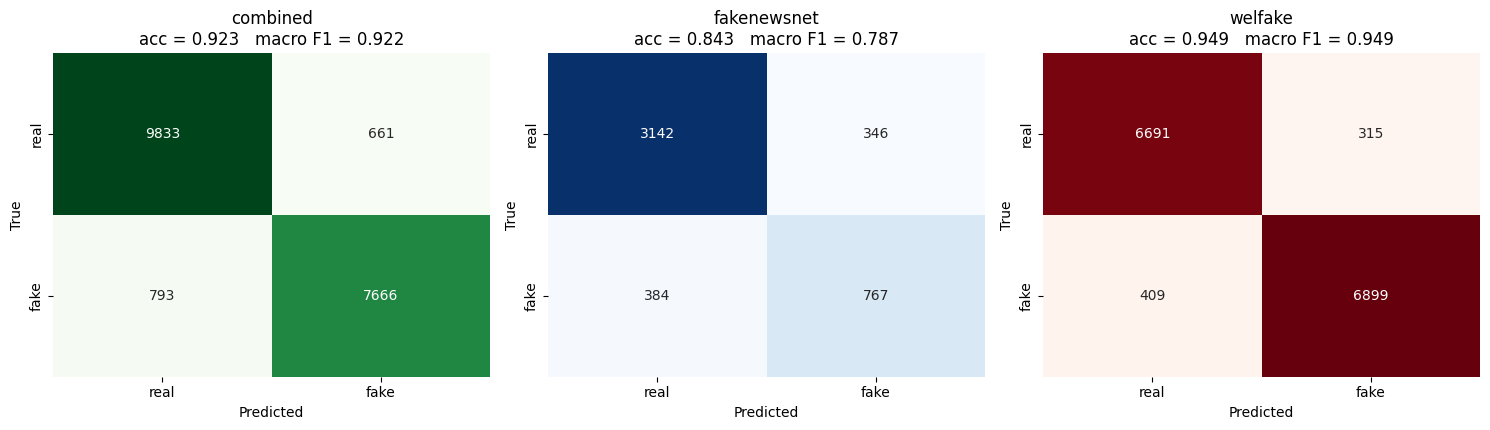


Saved figure to confusion_combined.png


In [29]:
pred_c   = trainer_c.predict(test_c_ds)
y_true_c = pred_c.label_ids
y_pred_c = np.argmax(pred_c.predictions, axis=-1)

test_c_eval = test_c.copy()
test_c_eval["pred"] = y_pred_c

slice_specs = [
    ("combined",    test_c_eval,                                  "Greens"),
    ("fakenewsnet", test_c_eval[test_c_eval["source"] == "fakenewsnet"], "Blues"),
    ("welfake",     test_c_eval[test_c_eval["source"] == "welfake"],     "Reds"),
]

slice_results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

for ax, (name, sub, cmap) in zip(axes, slice_specs):
    yt = sub["label"].to_numpy()
    yp = sub["pred"].to_numpy()
    acc = accuracy_score(yt, yp)
    f1m = f1_score(yt, yp, average="macro")
    slice_results[name] = {"n": len(sub), "acc": acc, "macro_f1": f1m}

    print(f"\n=== {name}  (n={len(sub)}) ===")
    print(f"  accuracy = {acc:.4f}   macro F1 = {f1m:.4f}")
    print(classification_report(yt, yp, target_names=["real", "fake"], digits=4))

    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["real", "fake"], yticklabels=["real", "fake"],
                cbar=False, ax=ax)
    ax.set_title(f"{name}\nacc = {acc:.3f}   macro F1 = {f1m:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
fig.savefig("confusion_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved figure to confusion_combined.png")

In [30]:
fn_slice_f1  = slice_results["fakenewsnet"]["macro_f1"]
wel_slice_f1 = slice_results["welfake"]["macro_f1"]

print("=" * 78)
print("Cross-dataset macro F1 — single-dataset vs combined training")
print("=" * 78)
print(f"{'Training data':<32} {'FakeNewsNet F1':>16} {'WELFake F1':>16}")
print("-" * 78)
print(f"{'FakeNewsNet only':<32} {0.811:>16.3f} {0.493:>16.3f}   (in / OOD)")
print(f"{'WELFake only':<32} {0.455:>16.3f} {0.994:>16.3f}   (OOD / in)")
print(f"{'Combined (FN + WELFake)':<32} {fn_slice_f1:>16.3f} {wel_slice_f1:>16.3f}   (in / in)")
print("=" * 78)
print("Single-dataset numbers from earlier sections of this notebook + CLAUDE.md.")
print("WELFake-only in-domain reported as accuracy in CLAUDE.md (0.994);")
print("WELFake is ~50/50 so macro F1 ≈ accuracy.")

if fn_slice_f1 > 0.493 and wel_slice_f1 > 0.455:
    print("\nResult: combined training improves both slices over single-dataset OOD.")
    print("Interpretation: the model can hold two style boundaries simultaneously.")
else:
    print("\nResult: at least one slice did not improve over single-dataset OOD.")
    print("Interpretation: combined training did not resolve the cross-domain gap.")


Cross-dataset macro F1 — single-dataset vs combined training
Training data                      FakeNewsNet F1       WELFake F1
------------------------------------------------------------------------------
FakeNewsNet only                            0.811            0.493   (in / OOD)
WELFake only                                0.455            0.994   (OOD / in)
Combined (FN + WELFake)                     0.787            0.949   (in / in)
Single-dataset numbers from earlier sections of this notebook + CLAUDE.md.
WELFake-only in-domain reported as accuracy in CLAUDE.md (0.994);
WELFake is ~50/50 so macro F1 ≈ accuracy.

Result: combined training improves both slices over single-dataset OOD.
Interpretation: the model can hold two style boundaries simultaneously.
